A/B Testing in Digital Marketing:
The goal of this A/B test is to compare campaign types "Awareness" and "Conversion" to determine which on performs better on the metric of conversion rates. 

Ho: The 'Conversion' Campaign Type does not have a significantly higher conversion rate than the 'Awareness' Campaign Type.
Ha: The 'Conversion' Campaign Type has a  significantly higher conversion rate than the 'Awareness' Campaign Type. 

In [18]:
import pandas as pd

In [19]:
# Import Data
df = pd.read_csv("/Users/lukepalmer-divers/Documents/Data Analysis/Datasets/digital_marketing_campaign_dataset.csv")

In [20]:
# check data types and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [21]:
# 0 missing values in all columns
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [CustomerID, Age, Gender, Income, CampaignChannel, CampaignType, AdSpend, ClickThroughRate, ConversionRate, WebsiteVisits, PagesPerVisit, TimeOnSite, SocialShares, EmailOpens, EmailClicks, PreviousPurchases, LoyaltyPoints, AdvertisingPlatform, AdvertisingTool, Conversion]
Index: []


In [22]:
# 0 duplicates found
# Understand data and structure
print(df.head())

   CustomerID  Age  Gender  Income CampaignChannel CampaignType      AdSpend  \
0        8000   56  Female  136912    Social Media    Awareness  6497.870068   
1        8001   69    Male   41760           Email    Retention  3898.668606   
2        8002   46  Female   88456             PPC    Awareness  1546.429596   
3        8003   32  Female   44085             PPC   Conversion   539.525936   
4        8004   60  Female   83964             PPC   Conversion  1678.043573   

   ClickThroughRate  ConversionRate  WebsiteVisits  PagesPerVisit  TimeOnSite  \
0          0.043919        0.088031              0       2.399017    7.396803   
1          0.155725        0.182725             42       2.917138    5.352549   
2          0.277490        0.076423              2       8.223619   13.794901   
3          0.137611        0.088004             47       4.540939   14.688363   
4          0.252851        0.109940              0       2.046847   13.993370   

   SocialShares  EmailOpens  Ema

In [23]:
# How many campaign types
print(df["CampaignType"].nunique())

4


In [24]:
# Delete unnessary columns 
# Filter for only "Awareness" and "Conversion" Campaign Types

columns_to_keep = ['CustomerID', 'CampaignType', 'ConversionRate']
filtered_df = df[df["CampaignType"].isin(["Awareness", "Conversion"])][columns_to_keep]
print(filtered_df)

      CustomerID CampaignType  ConversionRate
0           8000    Awareness        0.088031
2           8002    Awareness        0.076423
3           8003   Conversion        0.088004
4           8004   Conversion        0.109940
5           8005    Awareness        0.161316
...          ...          ...             ...
7985       15985   Conversion        0.059538
7986       15986    Awareness        0.130604
7994       15994    Awareness        0.082805
7995       15995    Awareness        0.116773
7999       15999    Awareness        0.057228

[4065 rows x 3 columns]


In [25]:
# Are the two groups independent of each other?
# create unique sets and use "&" intersection to see if there are any unique values in common. 

awareness_ids = set(df[df["CampaignType"] == "Awareness"]["CustomerID"])
conversion_ids = set(df[df["CampaignType"] == "Conversion"]["CustomerID"])
overlap = awareness_ids & conversion_ids
print(f"Number of overlapping customers: {len(overlap)}")

Number of overlapping customers: 0


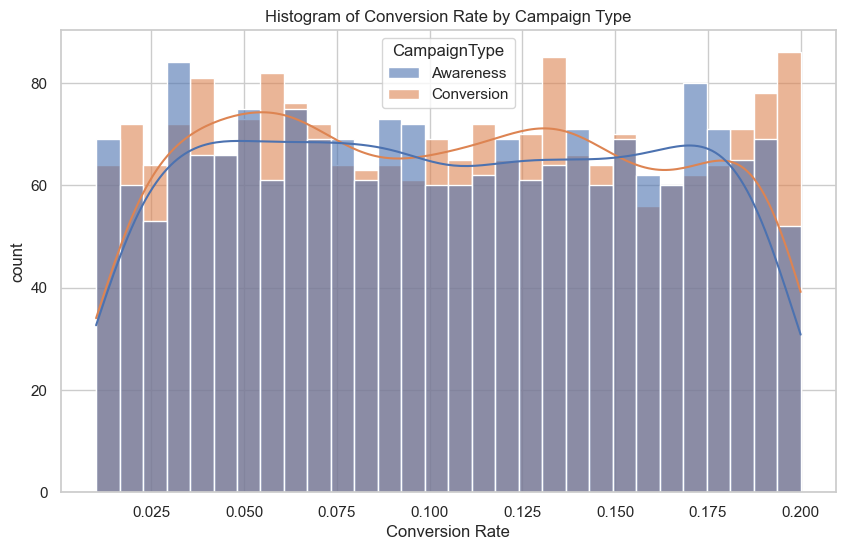

In [26]:
# Let's view the distributions of both campaign types. 
import seaborn as sns
import matplotlib.pyplot as plt

# set plot style
sns.set(style='whitegrid')

# plot distributions of campaigns
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_df, x="ConversionRate", hue="CampaignType", kde=True, bins=30, alpha=0.6)
plt.title("Histogram of Conversion Rate by Campaign Type")
plt.xlabel("Conversion Rate")
plt.ylabel("count")
plt.show()

In [27]:
# Now we can see that these Campaign Types don't have a normal distribution.
# Let's look at some summary statistics. 

filtered_df.groupby("CampaignType")["ConversionRate"].describe()

,count,mean,std,min,25%,50%,75%,max
CampaignType,,,,,,,,
Awareness,1988.0,0.104372,0.054690,0.010100,0.057045,0.103254,0.152712,0.199992
Conversion,2077.0,0.104859,0.055396,0.010094,0.056195,0.104578,0.151895,0.199995


<Axes: xlabel='CampaignType', ylabel='ConversionRate'>

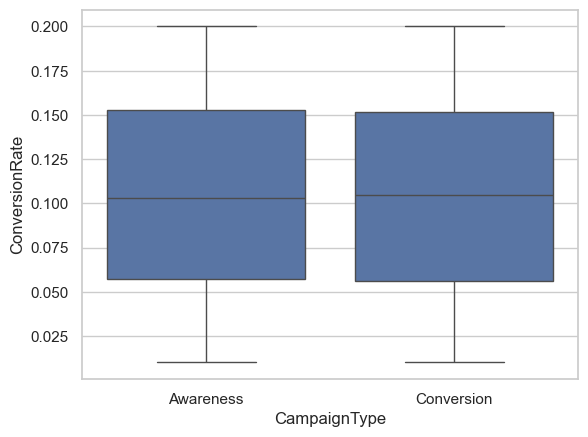

In [28]:
# show in a boxplot
sns.boxplot(data=filtered_df, x='CampaignType', y='ConversionRate')

In [29]:
# Could other variables be confounding the results?
df.groupby("CampaignType")[["Age", "Income", "PreviousPurchases", "LoyaltyPoints"]].mean()


,Age,Income,PreviousPurchases,LoyaltyPoints
CampaignType,,,,
Awareness,42.931590,85206.945674,4.370221,2502.743964
Consideration,43.537726,84316.079477,4.509054,2498.248994
Conversion,43.946076,84350.947520,4.574868,2490.987963
Retention,44.081664,84799.631228,4.483821,2468.614278


In [30]:
# The averages of the other variables are not significantly different from each other.  
# And we can see that there isn't a normal distribution from our histogram.
# Let's prove that with a Shapiro-Wilk test.
from scipy.stats import shapiro

# Split campaigns
awareness_campaign = filtered_df[filtered_df["CampaignType"] == "Awareness"]
conversion_campaign = filtered_df[filtered_df["CampaignType"] == "Conversion"]

# Perform Shapiro-Wilk test on Awareness Campaign
awareness_stat, awareness_p = shapiro(awareness_campaign["ConversionRate"])
print(f"Awareness Campaign - statistic: {awareness_stat}, P-value: {awareness_p}")

# Perform Shapiro-Wilk test on Conversion group
conversion_stat, conversion_p = shapiro(conversion_campaign["ConversionRate"])
print(f"Conversion group - statistic: {conversion_stat}, P-value: {conversion_p}")

# Interpret the results for Awareness group
if awareness_p > 0.05:
    print("The Awareness Group distribution is likely a normal distribution")
else:
    print("The Awareness Group distribution is likely NOT a normal distribution")

# Interpret the results for Conversion group
if conversion_p > 0.05:
    print("The Conversion Group distribution is likely a normal distribution")
else:
    print("The Conversion Group distribution is likely NOT a normal distribution")


Awareness Campaign - statistic: 0.9534923967166478, P-value: 1.1587335020303155e-24
Conversion group - statistic: 0.9534761564729226, P-value: 3.398116244508723e-25
The Awareness Group distribution is likely NOT a normal distribution
The Conversion Group distribution is likely NOT a normal distribution


In [31]:
# Are the vaiances equal?
# Let's use a Levene Test to find out.

from scipy.stats import levene

# Perform Levene's test
stat, p_value = levene(awareness_campaign["ConversionRate"], conversion_campaign["ConversionRate"])

print(f"Levene's Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpret the result
if p_value > 0.05:
    print("The variances of the groups are equal.")
else:
    print("The variances of the groups are NOT equal.")


Levene's Statistic: 0.4077622462594529
P-value: 0.5231434831842393
The variances of the groups are equal.


In [32]:
print(awareness_campaign)

      CustomerID CampaignType  ConversionRate
0           8000    Awareness        0.088031
2           8002    Awareness        0.076423
5           8005    Awareness        0.161316
6           8006    Awareness        0.060977
9           8009    Awareness        0.169786
...          ...          ...             ...
7975       15975    Awareness        0.029687
7986       15986    Awareness        0.130604
7994       15994    Awareness        0.082805
7995       15995    Awareness        0.116773
7999       15999    Awareness        0.057228

[1988 rows x 3 columns]


In [33]:
# Both the Awareness Group and the Conversion group do NOT have a normal distribution but their variance is equal. 
# So we cannot do a ttest. 
# We should use a Mann-Whitney U Test . 

from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U Test. 
stat, p_value = mannwhitneyu(
    awareness_campaign['ConversionRate'], 
    conversion_campaign['ConversionRate'],
    alternative='greater'
)

print(f"Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpret the results
if p_value > 0.05:
    print("Fail to reject the null Hypothesis: The Conversion campaign does NOT have a significantly higher conversion rate than the Awareness Campaign")
else:
    print("Reject the null hypothesis: The Cvonversion campaign does have a significantly higher conversion rate than the Awareness campaign")

Statistic: 2053870.0
P-value: 0.6122631776129032
Fail to reject the null Hypothesis: The Conversion campaign does NOT have a significantly higher conversion rate than the Awareness Campaign


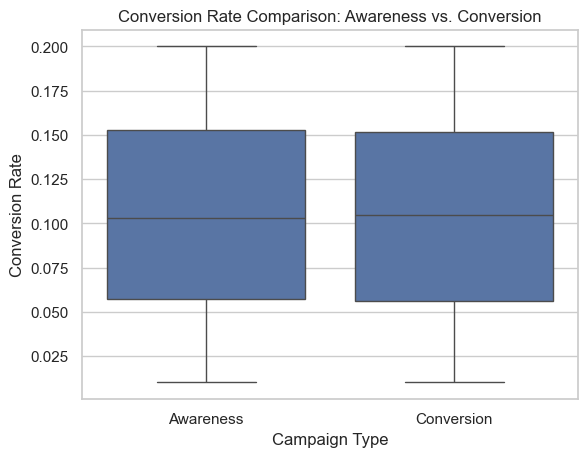

In [34]:
# Let's visualise the results. 
import seaborn as sns
import matplotlib.pyplot as plt

# Create a combined dataset for visualization
combined_data = pd.concat([awareness_campaign, conversion_campaign])

# Boxplot
sns.boxplot(x='CampaignType', y='ConversionRate', data=combined_data)
plt.title('Conversion Rate Comparison: Awareness vs. Conversion')
plt.xlabel('Campaign Type')
plt.ylabel('Conversion Rate')
plt.show()
